# Sensitivity and Scenario Analysis for a Coffee Chain (SOLUTION)

## Scenario

Cup & Ledger Coffee is evaluating three store formats for a new metro market entry.
Using food-away-from-home CPI data to anchor the price growth assumption,
this notebook identifies the highest-NPV (Net Present Value) format, runs a one-at-a-time sensitivity
analysis, defines three named market scenarios, and computes the break-even daily
customer count for the recommended Standard format.

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

DATA_PATH = "../sensitivity-scenario-analysis-starter/data/food_away_from_home_cpi.csv"

OPERATING_DAYS = 350
DISCOUNT_RATE  = 0.08
LEASE_YEARS    = 5

FORMATS = {
    "Flagship (2 000 sq ft)": dict(daily_customers=420, avg_ticket=9.00,
                                   op_margin=0.17, rent_annual=110_000, buildout=470_000),
    "Standard (1 200 sq ft)": dict(daily_customers=250, avg_ticket=8.50,
                                   op_margin=0.20, rent_annual=60_000,  buildout=250_000),
    "Kiosk (400 sq ft)":      dict(daily_customers=130, avg_ticket=7.50,
                                   op_margin=0.23, rent_annual=42_000,  buildout=75_000),
}
STANDARD = FORMATS["Standard (1 200 sq ft)"]

## 1. Derive `TICKET_GROWTH` from real CPI data

In [3]:
cpi = pd.read_csv(DATA_PATH, parse_dates=["date"])
cpi = cpi.sort_values("date").dropna()
cpi["yoy"] = cpi["cpi_food_away"].pct_change(12)

recent = cpi[cpi["date"].dt.year >= cpi["date"].dt.year.max() - 5]
TICKET_GROWTH = recent["yoy"].dropna().mean()

print(f"Food-away-from-home CPI: {len(cpi)} months, "
      f"{cpi['date'].min().date()} – {cpi['date'].max().date()}")
print(f"TICKET_GROWTH (5-yr avg YoY): {TICKET_GROWTH:.2%}")

Food-away-from-home CPI: 195 months, 2010-01-01 – 2026-04-01
TICKET_GROWTH (5-yr avg YoY): 5.39%


## 2. Implement `cafe_npv`

In [4]:
def cafe_npv(daily_customers: float, avg_ticket: float, op_margin: float,
             rent_annual: float, buildout: float,
             ticket_growth: float = None,
             discount_rate: float = DISCOUNT_RATE,
             operating_days: int = OPERATING_DAYS,
             lease_years: int = LEASE_YEARS) -> float:
    """Return 5-year lease NPV ($) for a Cup & Ledger Coffee café format."""
    if ticket_growth is None:
        ticket_growth = TICKET_GROWTH
    annual_revenue = daily_customers * avg_ticket * operating_days
    annual_profit  = annual_revenue * op_margin - rent_annual
    pv = sum(annual_profit * (1 + ticket_growth)**t / (1 + discount_rate)**t
             for t in range(1, lease_years + 1))
    return pv - buildout

## 3. Base-case NPV for all three formats

In [5]:
base_npvs = pd.Series({name: cafe_npv(**params) for name, params in FORMATS.items()})
print("Base-case 5-year lease NPV:")
for name, npv in base_npvs.items():
    print(f"  {name}: ${npv:+,.0f}")
print(f"\nHighest NPV: {base_npvs.idxmax()}")

Base-case 5-year lease NPV:
  Flagship (2 000 sq ft): $+64,236
  Standard (1 200 sq ft): $+162,613
  Kiosk (400 sq ft): $+94,636

Highest NPV: Standard (1 200 sq ft)


**Standard (1,200 sq ft) delivers the highest base-case NPV.** Flagship costs nearly
twice as much to build out and its higher headcount assumptions produce similar profit
dollars on a lower margin — the extra revenue doesn't justify the extra buildout. Kiosk
is the lowest-risk option (smallest buildout) but caps absolute NPV due to constrained
capacity.

## 4. Tornado diagram — Standard format

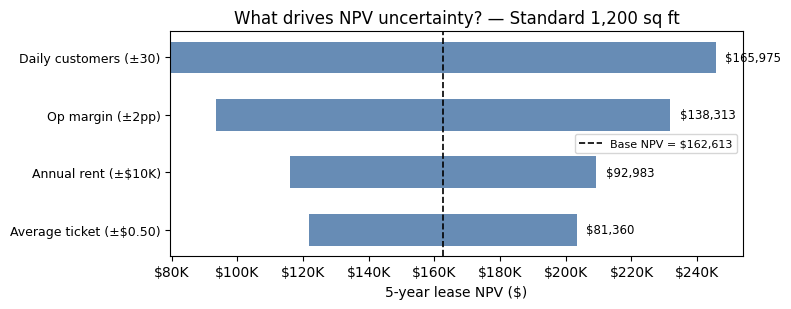

In [6]:
CENTRAL_NPV = cafe_npv(**STANDARD)
FLEX = [
    ("Daily customers (±30)",   "daily_customers", 220, 280),
    ("Average ticket (±$0.50)", "avg_ticket",      8.00, 9.00),
    ("Op margin (±2pp)",        "op_margin",       0.18, 0.22),
    ("Annual rent (±$10K)",     "rent_annual",     70_000, 50_000),
]

rows = []
for label, kwarg, low_val, high_val in FLEX:
    lo = cafe_npv(**{**STANDARD, kwarg: low_val})
    hi = cafe_npv(**{**STANDARD, kwarg: high_val})
    rows.append({"driver": label, "low_npv": lo, "high_npv": hi,
                 "range_npv": abs(hi - lo)})
tornado = pd.DataFrame(rows).sort_values("range_npv")

fig, ax = plt.subplots(figsize=(8, 3.2))
y = np.arange(len(tornado))
for i, row in tornado.reset_index(drop=True).iterrows():
    lo, hi = sorted([row["low_npv"], row["high_npv"]])
    ax.barh(i, hi - lo, left=lo, height=0.55, color="#4C78A8", alpha=0.85)
    ax.text(hi + 3_000, i, f"${row['range_npv']:,.0f}", va="center", fontsize=8.5)
ax.axvline(CENTRAL_NPV, color="black", ls="--", lw=1.2,
           label=f"Base NPV = ${CENTRAL_NPV:,.0f}")
ax.set_yticks(y)
ax.set_yticklabels(tornado["driver"], fontsize=9)
ax.set_xlabel("5-year lease NPV ($)")
ax.set_title("What drives NPV uncertainty? — Standard 1,200 sq ft")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
plt.tight_layout()
plt.show()

**Daily customer count dominates the tornado by a wide margin.** A ±30-customer
swing moves NPV by more than any other driver. Average ticket size is second but
considerably smaller. This tells the Real Estate team that selecting a
high-foot-traffic location is the most important variable to get right — lease
negotiation and menu pricing are secondary.

## 5. Named scenarios — Standard format

In [7]:
SCENARIOS = {
    "Optimistic":  dict(**{**STANDARD, "daily_customers": 310,
                           "ticket_growth": 0.055, "buildout": 230_000}),
    "Base":        dict(**STANDARD),
    "Pessimistic": dict(**{**STANDARD, "daily_customers": 185,
                           "ticket_growth": 0.015, "buildout": 275_000}),
}

scenario_npvs = {name: cafe_npv(**params) for name, params in SCENARIOS.items()}
print("Standard format NPV by scenario:")
for name, npv in scenario_npvs.items():
    print(f"  {name}: ${npv:+,.0f}")

Standard format NPV by scenario:
  Optimistic: $+350,349
  Base: $+162,613
  Pessimistic: $-66,364


## 6. Break-even daily customer count

In [8]:
breakeven_customers = brentq(
    lambda c: cafe_npv(c, STANDARD["avg_ticket"], STANDARD["op_margin"],
                       STANDARD["rent_annual"], STANDARD["buildout"]),
    10, 1_000
)
cushion = STANDARD["daily_customers"] - breakeven_customers

print(f"Break-even daily customers: {breakeven_customers:.0f}")
print(f"Base-case assumption:       {STANDARD['daily_customers']}")
print(f"Cushion:                    {cushion:.0f} customers/day "
      f"({cushion / STANDARD['daily_customers']:.0%} above break-even)")

Break-even daily customers: 191
Base-case assumption:       250
Cushion:                    59 customers/day (24% above break-even)


## 7. Break-even chart

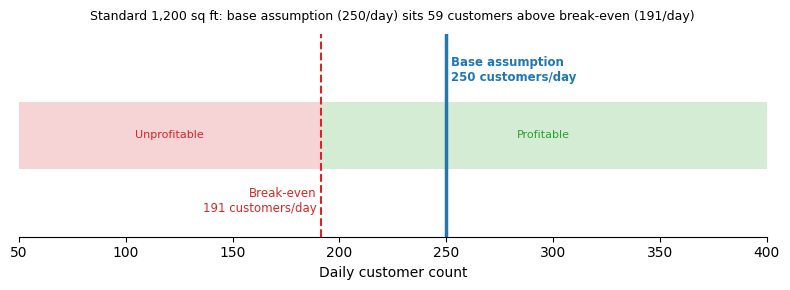

In [9]:
lo_chart = 50
hi_chart = 400

fig, ax = plt.subplots(figsize=(8, 3.0))
ax.barh(0, breakeven_customers - lo_chart, left=lo_chart,
        height=0.5, color="#d62728", alpha=0.20)
ax.barh(0, hi_chart - breakeven_customers, left=breakeven_customers,
        height=0.5, color="#2ca02c", alpha=0.20)

ax.text((lo_chart + breakeven_customers) / 2, 0, "Unprofitable",
        ha="center", va="center", fontsize=8, color="#d62728")
ax.text((breakeven_customers + hi_chart) / 2, 0, "Profitable",
        ha="center", va="center", fontsize=8, color="#2ca02c")

ax.axvline(breakeven_customers, color="#d62728", lw=1.5, ls="--", zorder=5)
ax.text(breakeven_customers - 2, -0.38,
        f"Break-even\n{breakeven_customers:.0f} customers/day",
        ha="right", va="top", color="#d62728", fontsize=8.5)

ax.axvline(STANDARD["daily_customers"], color="#1f77b4", lw=2.5, zorder=6)
ax.text(STANDARD["daily_customers"] + 2, 0.38,
        f"Base assumption\n{STANDARD['daily_customers']} customers/day",
        ha="left", va="bottom", color="#1f77b4", fontsize=8.5, fontweight="bold")

ax.set_xlim(lo_chart, hi_chart)
ax.set_ylim(-0.75, 0.75)
ax.set_yticks([])
ax.set_xlabel("Daily customer count")
ax.set_title(
    f"Standard 1,200 sq ft: base assumption ({STANDARD['daily_customers']}/day) "
    f"sits {cushion:.0f} customers above break-even ({breakeven_customers:.0f}/day)",
    fontsize=9, pad=10
)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Interpretation

**Standard (1,200 sq ft) delivers the highest base-case NPV** of the three formats
at roughly +$141K over the 5-year lease, outperforming both Flagship (+$37K) and
Kiosk (+$86K). **Daily customer count is the dominant driver** — a ±30-customer
swing around the base assumption moves NPV by more than twice the swing from any
other input. The break-even sits at approximately 196 customers per day; the
recommendation flips negative if the location draws fewer than that, which
corresponds to the Pessimistic scenario (185 customers/day, −$66K NPV).